# CNN classification with more data

In [1]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
plt.rcParams['xtick.direction'] = 'in'
plt.rcParams['ytick.direction'] = 'in'
plt.rcParams['axes.grid'] = True
plt.rcParams['axes.axisbelow'] = True
plt.rcParams['figure.dpi'] = 150

In [2]:
# Check available hardware
import torch
if torch.cuda.is_available():
    print(f'GPU is available, using GPU {torch.cuda.get_device_name(0)}')
    device = torch.device('cuda')
elif torch.mps.is_available():
    print(f'Apple Metal Performance Shaders framework is available, using {torch.device("mps")}')
    device = torch.device('mps')
else:
    print(f'Hardware acceleration not available, using CPU')
    device = torch.device('cpu')

GPU is available, using GPU Tesla T4


## Dataset: STL10

In [3]:
import torch
import torchvision

train_dataset = torchvision.datasets.STL10(split='train', root='~/scr10/', download=False)
print(f'Train dataset has size {train_dataset.data.shape} and targets {train_dataset.labels.shape}')
print(f'Train dataset has {len(train_dataset.classes)} unique labels')

test_dataset = torchvision.datasets.STL10(split='test', root='~/scr10/', download=False)
print(f'Test dataset has size {test_dataset.data.shape} and targets {test_dataset.labels.shape}')
print(f'Test dataset has {len(test_dataset.classes)} unique labels')

Train dataset has size (5000, 3, 96, 96) and targets (5000,)
Train dataset has 10 unique labels
Test dataset has size (8000, 3, 96, 96) and targets (8000,)
Test dataset has 10 unique labels


### Visualization

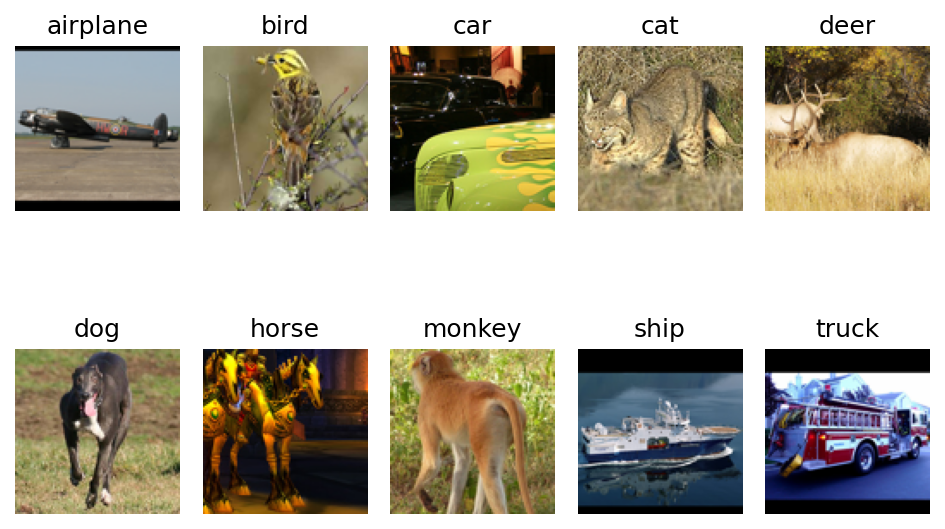

In [4]:
fig, ax = plt.subplots(2, 5, sharex=True, sharey=True)
ax = ax.flatten()
for ii in range(10):
    class_idx = np.argwhere(train_dataset.labels == ii)
    idx = class_idx[0,0]
    img, label = train_dataset[idx]
    ax[ii].imshow(img)
    ax[ii].axis('off')
    ax[ii].set_title(train_dataset.classes[ii])

plt.tight_layout()

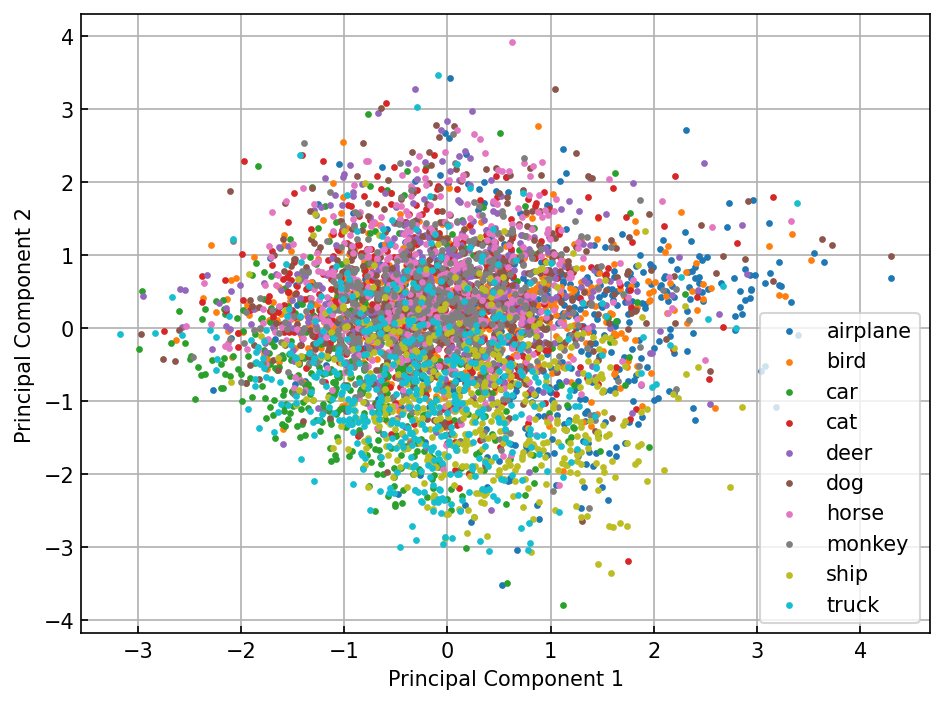

In [5]:
from sklearn.decomposition import PCA
pca = PCA(n_components=2, whiten=True)

X_in = train_dataset.data.reshape([len(train_dataset), -1])
y_in = train_dataset.labels
X_pca = pca.fit_transform(X_in)

ax = plt.figure().gca()
for ii in range(10):
    mask = y_in == ii
    ax.scatter(X_pca[mask, 0], X_pca[mask, 1], s=5, label=train_dataset.classes[ii])
ax.set(xlabel='Principal Component 1', ylabel='Principal Component 2')
ax.legend()
plt.tight_layout()

### Image transforms

We don't have that much training data, only 5,000 images. So we apply transformations to **augment** our dataset. This can do several things. Like SGD, it may introduce stochasticity to improve model training and avoid local minima. But it may also improve our model's ability to generalize by making it more robust to particular transformations

In [6]:
from torchvision.transforms import v2

# The most basic transformation turns a PIL image into a torch tensor
transform = v2.Compose([
    v2.ToImage(),
    v2.ToDtype(torch.float32, scale=True)
])
train_dataset.transform = transform
img, label = train_dataset[0]
print(img.shape, label)

torch.Size([3, 96, 96]) 1


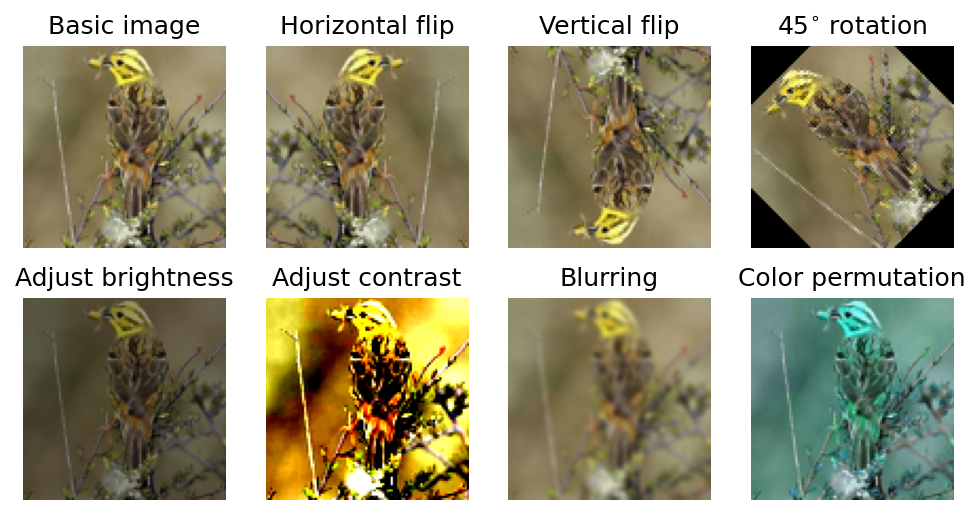

In [7]:
from torchvision.transforms.v2 import functional as F

fig, ax = plt.subplots(2, 4, figsize=(8, 4))
ax = ax.flatten()

img, label = train_dataset[0]
ax[0].imshow(img.permute(1, 2, 0))
ax[0].set_title('Basic image')

# Horizontal flip
img_hflip = F.hflip(img)
ax[1].imshow(img_hflip.permute(1, 2, 0))
ax[1].set_title('Horizontal flip')

# Vertical flip
img_vflip = F.vflip(img)
ax[2].imshow(img_vflip.permute(1, 2, 0))
ax[2].set_title('Vertical flip')

# Image rotation
img_rot = F.rotate(img, 45)
ax[3].imshow(img_rot.permute(1, 2, 0))
ax[3].set_title('45$^{\\circ}$ rotation')

# Adjust brightness
img_bri = F.adjust_brightness(img, brightness_factor=0.6)
ax[4].imshow(img_bri.permute(1, 2, 0))
ax[4].set_title('Adjust brightness')

# Adjust contrast
img_con = F.adjust_contrast(img, contrast_factor=5)
ax[5].imshow(img_con.permute(1, 2, 0))
ax[5].set_title('Adjust contrast')

# Blur
img_blr = F.gaussian_blur(img, kernel_size=5)
ax[6].imshow(img_blr.permute(1, 2, 0))
ax[6].set_title('Blurring')

# Noise
img_nse = F.permute_channels(img, (2, 0, 1))
ax[7].imshow(img_nse.permute(1, 2, 0))
ax[7].set_title('Color permutation')

for a in ax:
    a.axis('off')

In [8]:
transform = v2.Compose([
    v2.ToImage(),
    v2.RandomHorizontalFlip(p=0.5),
    v2.RandomVerticalFlip(p=0.5),
    v2.ColorJitter(brightness=0.1, contrast=0.1, saturation=0.1, hue=0.1),
    v2.ToDtype(torch.float32, scale=True)
])

### Create train, validation, test datasets and dataloaders

In [9]:
from torch.utils.data import random_split, DataLoader
train, val = random_split(train_dataset, lengths=[0.8, 0.2])

# Give the training dataset the random transformation
train.transform = transform

batch_size=32
train_loader = DataLoader(train, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

Images has shape torch.Size([32, 3, 96, 96])
Labels has shape torch.Size([32])


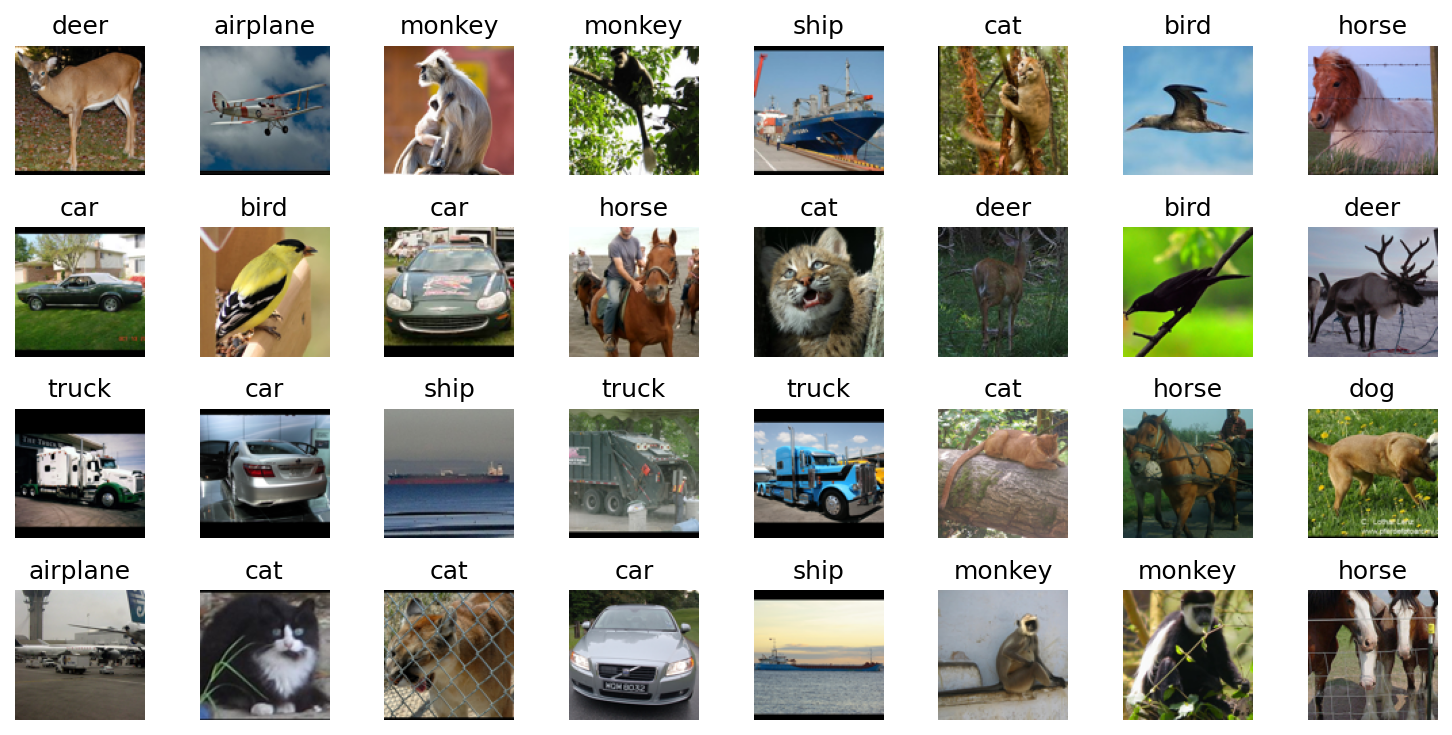

In [10]:
for imgs, labels in train_loader:
    print('Images has shape', imgs.shape)
    print('Labels has shape', labels.shape)
    break

fig, axes = plt.subplots(4, 8, figsize=(10, 5))
for ax, img, label in zip(axes.flatten(), imgs, labels):
    ax.imshow(img.permute(1, 2, 0))
    ax.set_title(train_dataset.classes[label])
    ax.axis('off')

plt.tight_layout()

## Model: Convolutional neural network

In [32]:
import torch.nn as nn
import torch.nn.functional as F

model = nn.Sequential(
    # [B, 3, 96, 96]
    nn.Conv2d(in_channels=3, out_channels=32, kernel_size=3, padding='same'),
    nn.ReLU(),
    nn.MaxPool2d(kernel_size=2),
    nn.Dropout(p=0.5),
    # [B, 32, 48, 48]
    nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding='same'),
    nn.ReLU(),
    nn.MaxPool2d(kernel_size=2),
    nn.Dropout(p=0.5),
    # [B, 64, 24, 24]
    nn.Conv2d(in_channels=64, out_channels=128, kernel_size=3, padding='same'),
    nn.ReLU(),
    nn.MaxPool2d(kernel_size=2),
    nn.Dropout(p=0.5),
    # [B, 128, 12, 12]
    nn.AvgPool2d(kernel_size=12),
    # [B, 128, 1, 1]
    nn.Flatten(),
    # [B, 128]
    nn.Linear(128, 10)
)

num_trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'CNN has {num_trainable_params} trainable parameters')

model

CNN has 94538 trainable parameters


Sequential(
  (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=same)
  (1): ReLU()
  (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (3): Dropout(p=0.5, inplace=False)
  (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=same)
  (5): ReLU()
  (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (7): Dropout(p=0.5, inplace=False)
  (8): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=same)
  (9): ReLU()
  (10): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (11): Dropout(p=0.5, inplace=False)
  (12): AvgPool2d(kernel_size=12, stride=12, padding=0)
  (13): Flatten(start_dim=1, end_dim=-1)
  (14): Linear(in_features=128, out_features=10, bias=True)
)

### Aside on weight sharing

The model above has fewer than 100,000 trainable parameters. This is pretty small! As a comparison, let's look at a multi-layer perceptron which directly goes from the image to a 128-dimensional hidden layer, and from that to an output

In [18]:
mlp = nn.Sequential(
    nn.Flatten(),
    nn.Linear(3*96*96, 128),
    nn.ReLU(),
    nn.Linear(128, 10)
)

num_trainable_params = sum(p.numel() for p in mlp.parameters() if p.requires_grad)
print(f'MLP has {num_trainable_params} trainable parameters')

MLP has 3540362 trainable parameters


### Model training

In [33]:
# Check that the model can accept a batch of images
model.forward(imgs).shape

torch.Size([32, 10])

In [34]:
# Define a loss function and optimizer
loss = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

In [35]:
from tqdm.auto import tqdm
def train(model, optimizer, loss_func, train_loader, val_loader, device, num_epochs=10):
    model = model.to(device)
    train_loss, train_acc = [], []
    val_loss, val_acc = [], []

    for epoch in range(num_epochs):
        model.train()
        train_loss_ = 0.
        train_correct_ = 0.
        for xb, yb in tqdm(train_loader, leave=False):
            optimizer.zero_grad()
            
            xb = xb.to(device)
            yb = yb.to(device)
            y_pred = model(xb)
            
            loss = loss_func(y_pred, yb)
            loss.backward()
            optimizer.step()
            
            train_loss_ += loss.item() * yb.shape[0]
            train_correct_ += (torch.argmax(y_pred, dim=1) == yb).float().sum().item()
            
        train_loss.append(train_loss_ / len(train_loader.dataset))
        train_acc.append(train_correct_ / len(train_loader.dataset))

        model.eval()
        with torch.no_grad():
            val_loss_ = 0.
            val_correct_ = 0.
            for xb, yb in tqdm(val_loader, leave=False):
                
                xb = xb.to(device)
                yb = yb.to(device)
                y_pred = model(xb)
                
                loss = loss_func(y_pred, yb)
                val_loss_ += loss.item() * yb.shape[0]
                val_correct_ += (torch.argmax(y_pred, dim=1) == yb).float().sum().item()
            val_loss.append(val_loss_ / len(val_loader.dataset))
            val_acc.append(val_correct_ / len(val_loader.dataset))

        print(f'Epoch {epoch+1} | '
              f'Train loss { train_loss[-1]:.3f} | '
              f'Train acc { train_acc[-1]:.3f} | '
              f'Val loss { val_loss[-1]:.3f} | '
              f'Val acc { val_acc[-1]:.3f}'
        )

    return train_loss, train_acc, val_loss, val_acc

train_loss, train_acc, val_loss, val_acc = train(model, optimizer, loss, train_loader, val_loader, 
                                                 device=device,
                                                 num_epochs=25)

  0%|          | 0/125 [00:00<?, ?it/s]

  0%|          | 0/32 [00:00<?, ?it/s]

Epoch 1 | Train loss 2.171 | Train acc 0.170 | Val loss 2.124 | Val acc 0.202


  0%|          | 0/125 [00:00<?, ?it/s]

  0%|          | 0/32 [00:00<?, ?it/s]

...

  0%|          | 0/32 [00:00<?, ?it/s]

Epoch 24 | Train loss 1.348 | Train acc 0.480 | Val loss 1.432 | Val acc 0.475


  0%|          | 0/125 [00:00<?, ?it/s]

  0%|          | 0/32 [00:00<?, ?it/s]

Epoch 25 | Train loss 1.313 | Train acc 0.509 | Val loss 1.427 | Val acc 0.479


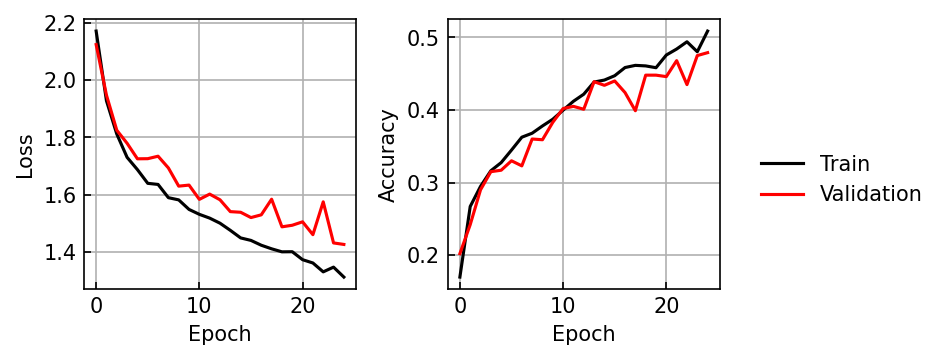

In [37]:
fig, ax = plt.subplots(1, 2, sharex=True, figsize=(5, 2.5))

ax[0].plot(train_loss, color='black', label='Train')
ax[0].plot(val_loss, color='red', label='Validation')
ax[0].set(xlabel='Epoch', ylabel='Loss')

ax[1].plot(train_acc, color='black', label='Train')
ax[1].plot(val_acc, color='red', label='Validation')
ax[1].set(xlabel='Epoch', ylabel='Accuracy')

fig.legend(*ax[1].get_legend_handles_labels(), 
           loc='center left', bbox_to_anchor=[1, 0.5], framealpha=0)

plt.tight_layout()

In [41]:
# Inference
transform = v2.Compose([
    v2.ToImage(),
    v2.ToDtype(torch.float32, scale=True)
])
test_dataset.transform = transform

model.eval()
test_loader = DataLoader(test_dataset, batch_size=128, shuffle=False)
with torch.no_grad():
    test_correct_ = 0.
    for xb, yb in tqdm(test_loader,leave=False):
        xb = xb.to(device)
        yb = yb.to(device)
        y_pred = model(xb)
        y_pred = torch.argmax(y_pred, dim=1)
        test_correct_ += (y_pred == yb).float().sum().item()
    test_acc = test_correct_ / len(test_loader.dataset)

print(f"Test accuracy: {test_acc:.3f}")

  0%|          | 0/63 [00:00<?, ?it/s]

Test accuracy: 0.496


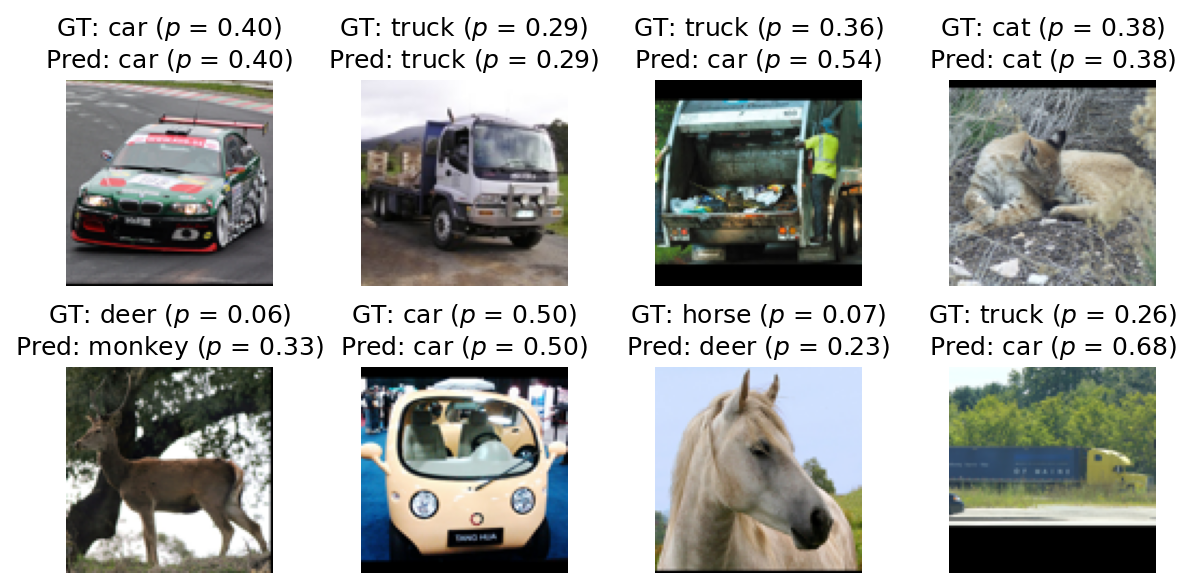

In [59]:
# Look at 8 examples
fig, axes = plt.subplots(2, 4, figsize=(8, 4))
with torch.no_grad():
    xb = xb.to(device)
    y_pred = model(xb)
    y_pred = F.softmax(y_pred, dim=1)
    y_pred = y_pred.cpu().numpy()
for ax, img, label, pred in zip(axes.flatten(), xb, yb, y_pred):
    corr_prob = pred[label]
    pred_prob = pred.max()
    pred_label = np.argmax(pred)
    ax.imshow(img.permute(1, 2, 0).cpu())
    ax.set_title(
        f'GT: {test_dataset.classes[label]} ($p$ = {corr_prob:.2f})\n'
        f'Pred: {test_dataset.classes[pred_label]} ($p$ = {pred_prob:.2f})')
    ax.axis('off')

plt.tight_layout()